## biblioteke

In [3]:
import os
import h5py
import pandas as pd

BASE_DIR = './MillionSongSubset'

In [4]:
from implicit.als import AlternatingLeastSquares
import pickle

## ucitavanje datasetova

In [5]:
df_test = pd.read_csv('df_test2.csv')
df_val = pd.read_csv('df_val2.csv')
df_train = pd.read_csv('df_train2.csv')
df_trainveci = pd.read_csv('df_trainveci2.csv')

In [6]:
df_test.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,mode,tempo,time_signature,similar_artists
0,bn,SOLFDCM12A6D4F7A7C,1,ARBEBBY1187B9B43DB,"['heartland rock', 'jam band', 'pop rock', 'so...",0.817503,0.0,0.642801,0.571429,"['ARSAIUN1187FB398D3', 'ARF4L041187FB4D318', '..."
1,(throwback),SONTFNG12A8C13FF69,1,AR52EZT1187B9900BF,"['neo soul', 'blues', 'soul', 'pop', 'urban']",0.827999,1.0,0.450002,0.571429,"['AR5DC8S1187B9958BE', 'ARVP1TO1187B9A4A7A', '..."
2,2000s pop,SOYMPFK12A8C141D1A,1,ARJGIOD1187B9AE920,"['teen pop', 'pop', 'adult contemporary', 'bal...",0.875136,1.0,0.517121,0.571429,"['AR6BH9N1187B99E437', 'ARBAW9R1187B98FB6B', '..."
3,60's,SOBDYCT12AB0183AF5,1,ARAJPHH1187FB5566A,"['doo-wop', 'ballad', 'pop rock', 'rock steady...",0.730008,1.0,0.250244,0.571429,"['ARXY7M01187B9B7611', 'ARFXVDO11F4C83EE99', '..."
4,60s,SOOOROX12A6D4F8400,1,ARWY7I71187FB36C3D,"['brill building pop', 'oldies', 'ballad', 'so...",0.815032,1.0,0.491279,0.142857,"['ARAJPHH1187FB5566A', 'ARUE3AK1187B9AC923', '..."


In [7]:
df_train.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,mode,tempo,time_signature,similar_artists
0,bn,SOSKFIT12A8C14224A,1,ARM7EDF1187B9B3FA1,"['heavy metal', 'hard rock', 'rock', 'metal', ...",0.914632,1.0,0.510554,1.000000,"['ARE8GLF1187FB52532', 'ARKUDKL1296AAF0B2F', '..."
1,2000s pop,SOPVXLX12A8C1402D5,1,AR3JMC51187B9AE49D,"['teen pop', 'pop', 'rock', 'adult contemporar...",0.891092,1.0,0.429129,0.571429,"['AR03BDP1187FB5B324', 'AR5YRCN1187B98E3C8', '..."
2,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
3,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
4,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."


In [8]:
df_trainveci.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,mode,tempo,time_signature,similar_artists
0,bn,SOSKFIT12A8C14224A,1,ARM7EDF1187B9B3FA1,"['heavy metal', 'hard rock', 'rock', 'metal', ...",0.914632,1.0,0.510554,1.000000,"['ARE8GLF1187FB52532', 'ARKUDKL1296AAF0B2F', '..."
1,2000s pop,SOPVXLX12A8C1402D5,1,AR3JMC51187B9AE49D,"['teen pop', 'pop', 'rock', 'adult contemporar...",0.891092,1.0,0.429129,0.571429,"['AR03BDP1187FB5B324', 'AR5YRCN1187B98E3C8', '..."
2,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
3,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
4,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."


In [9]:
df_val.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,mode,tempo,time_signature,similar_artists
0,(throwback),SOMTXSB12AF72ACC38,1,AR03BDP1187FB5B324,"['dance pop', 'teen pop', 'pop rock', 'electro...",0.889464,1.0,0.361704,0.571429,"['ARX6TAQ11C8A415850', 'ARY7CAU1187B98A4F6', '..."
1,60's,SOFDYYA12A58A78E73,1,ARH8VT91187FB49CA2,"['all-female', 'doo-wop', 'northern soul', 'ba...",0.820357,1.0,0.339926,0.571429,"['ARXY7M01187B9B7611', 'ARNUFGE1187B9B7881', '..."
2,60s,SOJMOQU12AC468B167,1,ARDY3451187B9A0226,"['country rock', 'ballad', 'chanson', 'nashvil...",0.827118,1.0,0.513381,0.142857,"['ARA7YDA1187B9A5776', 'ARGKD4W1187B990E04', '..."
3,70's and 80's,SOSKFIT12A8C14224A,1,ARM7EDF1187B9B3FA1,"['heavy metal', 'hard rock', 'rock', 'metal', ...",0.914632,1.0,0.510554,1.000000,"['ARE8GLF1187FB52532', 'ARKUDKL1296AAF0B2F', '..."
4,80s Hits,SOCWJDB12A58A776AF,1,ARWPYQI1187FB4D55A,"['dance pop', 'rock', 'pop', 'england', 'adult...",0.840717,1.0,0.431305,0.571429,"['ARCJMMQ1187B98D1FD', 'ARY7CAU1187B98A4F6', '..."


## priprema za content based

In [23]:
df_train_cb = df_train.drop(columns=["play_count"]).copy()
df_test_cb = df_test.drop(columns=["play_count"]).copy()
df_val_cb = df_val.drop(columns=["play_count"]).copy()
df_trainveci_cb = df_trainveci.drop(columns=["play_count"]).copy()

print(len(df_trainveci_cb))
print(len(df_train_cb))
print(len(df_test_cb))
print(len(df_val_cb))

display(df_train_cb.head())

200339
168633
54319
40419


,user_id,song_id,artist_id,artist_terms,loudness,mode,tempo,time_signature,similar_artists
0,bn,SOSKFIT12A8C14224A,ARM7EDF1187B9B3FA1,"['heavy metal', 'hard rock', 'rock', 'metal', ...",0.914632,1.0,0.510554,1.000000,"['ARE8GLF1187FB52532', 'ARKUDKL1296AAF0B2F', '..."
1,2000s pop,SOPVXLX12A8C1402D5,AR3JMC51187B9AE49D,"['teen pop', 'pop', 'rock', 'adult contemporar...",0.891092,1.0,0.429129,0.571429,"['AR03BDP1187FB5B324', 'AR5YRCN1187B98E3C8', '..."
2,60's,SONFECQ12AB017EFF7,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
3,60's,SONFECQ12AB017EFF7,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
4,60's,SONFECQ12AB017EFF7,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,1.0,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."


In [24]:
df_finalni = pd.concat([df_train_cb, df_test_cb])
print(len(df_finalni))
print(len(df_test_cb))
print(len(df_train_cb))

222952
54319
168633


In [25]:
import ast

def pripremi_terms(terms_list):
    if isinstance(terms_list, str):
        try:
            terms_list = ast.literal_eval(terms_list)
        except (ValueError, SyntaxError):
            return "" 
            
    if not isinstance(terms_list, list) or len(terms_list) == 0: 
        return ""
        
    return " ".join([term.replace(" ", "_") for term in terms_list])

In [26]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

if not df_train.empty and not df_test.empty:
    
   
    def pripremi_terms(terms_list):
        if isinstance(terms_list, str):
            try:
                terms_list = ast.literal_eval(terms_list)
            except (ValueError, SyntaxError):
                return "" 
                
        if not isinstance(terms_list, list) or len(terms_list) == 0: 
            return ""
            
        return " ".join([term.replace(" ", "_") for term in terms_list])
    df_train['terms_clean_text'] = df_train['artist_terms'].apply(pripremi_terms)
    df_test['terms_clean_text'] = df_test['artist_terms'].apply(pripremi_terms)

    tfidf = TfidfVectorizer(max_features=1000)
    tfidf_matrica_tr = tfidf.fit_transform(df_train['terms_clean_text'])
    tfidf_matrica_te = tfidf.transform(df_test['terms_clean_text'])

    print(f"Oblik TF-IDF matrice (Pesme x Karakteristike): {tfidf_matrica_tr.shape}")
    print(f"Oblik TF-IDF matrice (Pesme x Karakteristike): {tfidf_matrica_te.shape}")

    nauceni_tagovi = tfidf.get_feature_names_out()
    print(f"Neki od naučenih tagova: {nauceni_tagovi[:10]}")

Oblik TF-IDF matrice (Pesme x Karakteristike): (168633, 604)
Oblik TF-IDF matrice (Pesme x Karakteristike): (54319, 604)
Neki od naučenih tagova: ['2_tone' '60s' '70s' '80s_pop' 'abstract' 'acid_jazz' 'acoustic'
 'adult_contemporary' 'africa' 'afrobeat']


In [27]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

if not df_finalni.empty:

    def pripremi_terms(terms_list):
        if not isinstance(terms_list, list) or len(terms_list) == 0:
            return ""
        return " ".join([term.replace(" ", "_") for term in terms_list])

    df_finalni["terms_clean_text"] = df_finalni["artist_terms"].apply(
        pripremi_terms
    )

    tfidf_matrica = tfidf.transform(df_finalni["terms_clean_text"])

    ts_min = df_finalni["time_signature"].fillna(0).min()
    ts_max = df_finalni["time_signature"].fillna(0).max()

    if ts_max != ts_min:
        time_sig_norm = (df_finalni["time_signature"].fillna(0) - ts_min) / (
            ts_max - ts_min
        )
    else:
        time_sig_norm = df_finalni["time_signature"].fillna(0)

    l_norm = df_finalni["loudness"].values
    t_norm = df_finalni["tempo"].values
    m_norm = df_finalni["mode"].values
    ts_norm = time_sig_norm.values

    numericke_karakteristike = np.vstack([l_norm, t_norm, m_norm,ts_norm]).T
    numericke_sparse = csr_matrix(numericke_karakteristike)

    tfidf_matrix = hstack([tfidf_matrica, numericke_sparse]).tocsr()

    print(
        f"Pesme x Sve karakteristike {tfidf_matrix.shape}"
    )

Pesme x Sve karakteristike (222952, 608)


In [28]:
tekstualni_nizovi = df_finalni["artist_terms"].apply(
    lambda x: (
        " ".join([tag.replace(" ", "_") for tag in x])
        if isinstance(x, list)
        else ""
    )
)

song_id_u_indeks = {
    song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])
}


pesme_u_matrici = set(df_finalni["song_id"].unique())
df_interactions_sigurno = df_finalni[
    df_finalni["song_id"].isin(pesme_u_matrici)
].copy()

target_user_id = df_interactions_sigurno["user_id"].value_counts().index[0]

## content based - trening i evaluacija

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split


def evaluiraj_maksimalni_cb(
    df_train,
    df_test,
    kombinovana_matrica,
    song_id_u_indeks,
    df_pesme,
    top_n=10,
):
    ukupno_hitova = 0
    ukupno_preciznost = 0.0
    ukupno_recall = 0.0        
    ukupno_ap = 0.0            
    ukupno_ndcg = 0.0          
    procenjeni_korisnici = 0

    test_users = df_test["user_id"].unique()
    kombinovana_matrica = kombinovana_matrica.tocsr()
    kombinovana_matrica.data = np.nan_to_num(kombinovana_matrica.data)

    for target_user_id in test_users:
        user_train = df_train[df_train["user_id"] == target_user_id]
        if user_train.empty:
            continue

        user_test_pesme = set(
            df_test[df_test["user_id"] == target_user_id]["song_id"]
        )

        if len(user_test_pesme) == 0:
            continue

        profil_korisnika = sp.csr_matrix(
            (1, kombinovana_matrica.shape[1]), dtype=np.float64
        )

        for _, red in user_train.iterrows():
            s_id = red["song_id"]
            if s_id in song_id_u_indeks:
                idx_p = song_id_u_indeks[s_id]
                profil_korisnika += kombinovana_matrica.getrow(idx_p)

        skorovi = cosine_similarity(
            profil_korisnika, kombinovana_matrica
        ).flatten()
        top_indeksi = np.argsort(skorovi)[::-1]

        skup_slusanih_id = set(user_train["song_id"])
        preporuke_id = []
        vec_dodato = set()

        for idx in top_indeksi:
            pesma_info = df_pesme.iloc[idx]
            s_id = pesma_info["song_id"]

            if s_id not in skup_slusanih_id and s_id not in vec_dodato:
                preporuke_id.append(s_id)
                vec_dodato.add(s_id)

            if len(preporuke_id) == top_n:
                break

        pogoci = [pesma for pesma in preporuke_id if pesma in user_test_pesme]
        broj_pogodaka = len(pogoci)

        if broj_pogodaka > 0:
            ukupno_hitova += 1

        ukupno_preciznost += broj_pogodaka / top_n
        ukupno_recall += broj_pogodaka / len(user_test_pesme)

        # 1. Računanje Average Precision (za MAP)
        korisnik_ap = 0.0
        trenutni_pogoci = 0
        for i, pesma in enumerate(preporuke_id):
            if pesma in user_test_pesme:
                trenutni_pogoci += 1
                korisnik_ap += trenutni_pogoci / (i + 1)
        
        maksimalno_mogucih_pogodaka = min(top_n, len(user_test_pesme))
        if maksimalno_mogucih_pogodaka > 0:
            ukupno_ap += korisnik_ap / maksimalno_mogucih_pogodaka

        # 2. Računanje NDCG
        korisnik_dcg = 0.0
        for i, pesma in enumerate(preporuke_id):
            if pesma in user_test_pesme:
                korisnik_dcg += 1.0 / np.log2(i + 2)

        korisnik_idcg = 0.0
        for i in range(maksimalno_mogucih_pogodaka):
            korisnik_idcg += 1.0 / np.log2(i + 2)

        if korisnik_idcg > 0:
            ukupno_ndcg += korisnik_dcg / korisnik_idcg

        procenjeni_korisnici += 1

    
    prosecan_hr = (
        ukupno_hitova / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    )
    prosecna_preciznost = (
        ukupno_preciznost / procenjeni_korisnici
        if procenjeni_korisnici > 0
        else 0
    )
    prosecan_recall = (
        ukupno_recall / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    )
    prosecan_map = (
        ukupno_ap / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    )
    prosecan_ndcg = (
        ukupno_ndcg / procenjeni_korisnici if procenjeni_korisnici > 0 else 0
    )

    if (prosecna_preciznost + prosecan_recall) > 0:
        f1_skor = (
            2
            * (prosecna_preciznost * prosecan_recall)
            / (prosecna_preciznost + prosecan_recall)
        )
    else:
        f1_skor = 0.0

    print(f"Evaluirano korisnika: {procenjeni_korisnici}")
    print(f"Hit Rate@{top_n}:     {prosecan_hr:.4f}")
    print(f"Precision@{top_n}:    {prosecna_preciznost:.4f}")
    print(f"Recall@{top_n}:       {prosecan_recall:.4f}")  
    print(f"F1-Score@{top_n}:     {f1_skor:.4f}")  
    print(f"MAP@{top_n}:          {prosecan_map:.4f}")  
    print(f"NDCG@{top_n}:         {prosecan_ndcg:.4f}")  

    return prosecan_hr, prosecna_preciznost, prosecan_recall, f1_skor, prosecan_map, prosecan_ndcg


izvor_interakcija = df_finalni
# df_train = pd.read_csv("df_trainveci.csv")
# df_test = pd.read_csv("df_test.csv")
# df_val = pd.read_csv("df_val.csv")
song_id_u_indeks = {
    song_id: idx for idx, song_id in enumerate(df_finalni["song_id"])
}

hr_full, prec_full, rec_full, f1_full, map_full, ndcg_full = evaluiraj_maksimalni_cb(
    df_train=df_train,
    df_test=df_test,
    kombinovana_matrica=tfidf_matrica,
    song_id_u_indeks=song_id_u_indeks,
    df_pesme=df_finalni,
    top_n=10,
)

## priprema za model based

In [10]:
df_train_als = df_train.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_train_als.sample(5)

,user_id,song_id,play_count,mode
55113,Jamz,SOLWCYO12A5829149B,1,1.0
78136,R&B,SONTFNG12A8C13FF69,1,1.0
135923,low key,SOEYHBE12AB01848F6,1,0.0
47206,Good Good,SOSGQPS12A8AE48538,1,1.0
79100,ROADTRIPPIN,SOSGQPS12A8AE48538,1,1.0


In [11]:
df_test_als = df_test.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_test_als.sample(5)

,user_id,song_id,play_count,mode
52424,throwbacks,SOSGQPS12A8AE48538,1,1.0
37317,b86a6aa026706b23688fbbf2f1de0da50668aa99,SOEHWGF12A6D4F8B2B,2,0.0
41462,fc3d4c596537f0ffbd69706f634ec29478011637,SOEHISP12AB0188417,3,1.0
13375,Engagement Party,SOGWZBN12A6D4F6AB2,1,1.0
50510,tbt,SOIJEWM12A67ADA08D,1,1.0


In [12]:
df_val_als = df_val.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_val_als.sample(5)

,user_id,song_id,play_count,mode
21045,Rock en Español,SOLLARE12A8C136DF8,1,0.0
20365,Rock,SOOKISK12AB0180667,1,1.0
17936,Party,SOBQRZJ12A6310E1F8,1,1.0
39585,wedding,SOAOPVN12AAF3B1856,1,0.0
37814,throwback,SOSKFIT12A8C14224A,1,1.0


In [13]:
df_trainveci_als = df_trainveci.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_trainveci_als.sample(5)

,user_id,song_id,play_count,mode
165490,wedding,SOFQBMN12A8C1428AD,1,0.0
188280,a02de1b5ae4aee9bef58fabfd292363b150717a8,SOOSBQP12A8C1353B6,1,1.0
5946,2017,SOGVJTG12A6701E991,1,1.0
180582,62f928f8979571b683eb56852b9072caa8595069,SORJVDO12AF72A1970,1,0.0
110969,Werk,SODJUSQ12A8AE486C6,1,0.0


In [14]:
# brisanje duplikata
df_als = df_train_als.groupby(['user_id', 'song_id'])['play_count'].sum().reset_index()


user_cat = df_als['user_id'].astype('category')
song_cat = df_als['song_id'].astype('category')

# mapiranje
user_map = {cat: i for i, cat in enumerate(user_cat.cat.categories)}
song_map = {cat: i for i, cat in enumerate(song_cat.cat.categories)}

df_als['user_id_idx'] = df_als['user_id'].map(user_map)
df_als['song_id_idx'] = df_als['song_id'].map(song_map)

# mapiranje na val i test a koristimo mapiranje od traina
df_test_als = df_test.copy()
df_test_als['user_id_idx'] = df_test_als['user_id'].map(user_map)
df_test_als['song_id_idx'] = df_test_als['song_id'].map(song_map)
df_test_als = df_test_als.dropna(subset=['user_id_idx', 'song_id_idx'])

df_val_als = df_val.copy()
df_val_als['user_id_idx'] = df_val_als['user_id'].map(user_map)
df_val_als['song_id_idx'] = df_val_als['song_id'].map(song_map)
df_val_als = df_val_als.dropna(subset=['user_id_idx', 'song_id_idx'])

# sparse matrica za als
from scipy.sparse import csr_matrix

sparse_item_user = csr_matrix(
    (df_als['play_count'], (df_als['song_id_idx'], df_als['user_id_idx']))
)

print("Podaci su spremni!")
print(f"Dimenzije matrice: {sparse_item_user.shape}")
print(f"Train interakcije: {len(df_als)}, Test: {len(df_test_als)}, Val: {len(df_val_als)}")

Podaci su spremni!
Dimenzije matrice: (2262, 26974)
Train interakcije: 92934, Test: 50251, Val: 36505


## ials - trening i evaluacija

C:\Users\Stankovic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Iteracija 01: MAP@10 = 0.0475 | NDCG@10 = 0.0687 | Precision@10 = 0.0931
Iteracija 02: MAP@10 = 0.1289 | NDCG@10 = 0.1801 | Precision@10 = 0.2417
Iteracija 03: MAP@10 = 0.1442 | NDCG@10 = 0.1995 | Precision@10 = 0.2621
Iteracija 04: MAP@10 = 0.1475 | NDCG@10 = 0.2039 | Precision@10 = 0.2676
Iteracija 05: MAP@10 = 0.1482 | NDCG@10 = 0.2050 | Precision@10 = 0.2696
Iteracija 06: MAP@10 = 0.1491 | NDCG@10 = 0.2063 | Precision@10 = 0.2720
Iteracija 07: MAP@10 = 0.1490 | NDCG@10 = 0.2061 | Precision@10 = 0.2718
Iteracija 08: MAP@10 = 0.1504 | NDCG@10 = 0.2073 | Precision@10 = 0.2726
Iteracija 09: MAP@10 = 0.1505 | NDCG@10 = 0.2078 | Precision@10 = 0.2732
Iteracija 10: MAP@10 = 0.1502 | NDCG@10 = 0.2074 | Precision@10 = 0.2731
Iteracija 11: MAP@10 = 0.1504 | NDCG@10 = 0.2079 | Precision@10 = 0.2738
Iteracija 12: MAP@10 = 0.1508 | NDCG@10 = 0.2084 | Precision@10 = 0.2747
Iteracija 13: MAP@10 = 0.1511 | NDCG@10 = 0.2087 | Precision@10 = 0.2747
Iteracija 14: MAP@10 = 0.1510 | NDCG@10 = 0.2086 | 

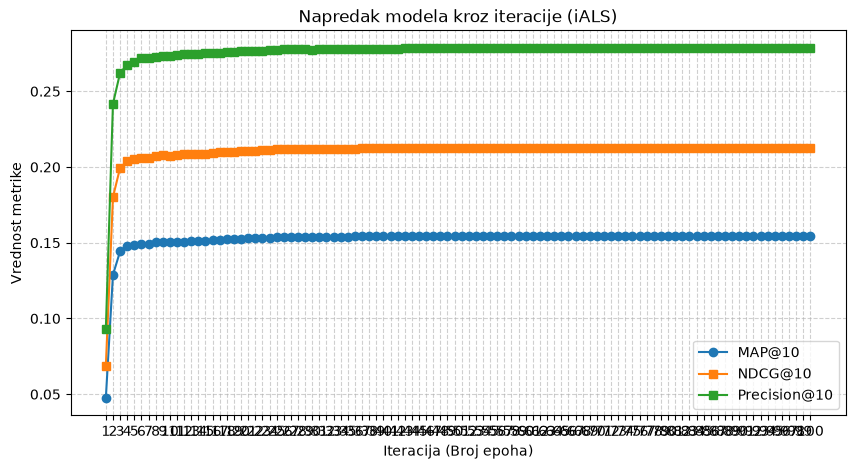

In [ ]:
import os
import pickle
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import ranking_metrics_at_k

# parametri
broj_faktora = 120
regularizacija = 30
K_ZA_EVALUACIJU = 10  # k za map@k i ndcg@k

ime_podfoldera = f'model_manji_f{broj_faktora}_reg{regularizacija}' 
putanja_foldera = os.path.join('sacuvani_modeli', ime_podfoldera)

if not os.path.exists(putanja_foldera):
    os.makedirs(putanja_foldera)

# matrica za tr
user_item_matrix = sparse_item_user.T.tocsr()


val_user_indices = df_val_als['user_id_idx'].astype(int).values
val_item_indices = df_val_als['song_id_idx'].astype(int).values
val_values = df_val_als.get('play_count', [1] * len(df_val_als)) # ako nema play_count, stavlja jedinice

val_matrix = csr_matrix(
    (val_values, (val_user_indices, val_item_indices)), 
    shape=user_item_matrix.shape
)

# liste za čuvanje istorije metrika
istorija_map = []
istorija_ndcg = []
istorija_preciznosti = []
istorija_hr = []

br_epoha = 100

# petlja kroz epohe
for i in range(1, br_epoha+1): 
    # inicijalizujemo model sa 'i' iteracija i fiksiranim random_state-om
    model = AlternatingLeastSquares(
        factors=broj_faktora, 
        regularization=regularizacija, 
        iterations=i, 
        random_state=42
    )
    
    # Treniranje modela od početne tačke do iteracije 'i'
    model.fit(user_item_matrix, show_progress=False) 
    
    # Čuvanje modela na disk
    ime_fajla = os.path.join(putanja_foldera, f'epoha_{i:02d}.pkl')
    with open(ime_fajla, 'wb') as f:
        pickle.dump(model, f)
    
    # 4. NAPREDNA EVALUACIJA (MAP i NDCG)
    # Ova funkcija automatski filtrira stvari koje je korisnik već video u train setu!
    metrike = ranking_metrics_at_k(
        model, 
        train_user_items=user_item_matrix, 
        test_user_items=val_matrix, 
        K=K_ZA_EVALUACIJU,
        show_progress=False
    )
    
    trenutni_map = metrike['map']
    trenutni_ndcg = metrike['ndcg']
    trenutni_prec = metrike['precision']
    
    istorija_map.append(trenutni_map)
    istorija_ndcg.append(trenutni_ndcg)
    istorija_preciznosti.append(trenutni_prec)
    
    print(f"Iteracija {i:02d}: MAP@{K_ZA_EVALUACIJU} = {trenutni_map:.4f} | NDCG@{K_ZA_EVALUACIJU} = {trenutni_ndcg:.4f} | Precision@{K_ZA_EVALUACIJU} = {trenutni_prec:.4f}")

# grafik toka treninga
plt.figure(figsize=(10, 5))
plt.plot(range(1, br_epoha+1), istorija_map, marker='o', label=f'MAP@{K_ZA_EVALUACIJU}')
plt.plot(range(1, br_epoha+1), istorija_ndcg, marker='s', label=f'NDCG@{K_ZA_EVALUACIJU}')
plt.plot(range(1, br_epoha+1), istorija_preciznosti, marker='s', label=f'Precision@{K_ZA_EVALUACIJU}')
plt.xlabel('Iteracija (Broj epoha)')
plt.ylabel('Vrednost metrike')
plt.title('Napredak modela kroz iteracije (iALS)')
plt.xticks(range(1, br_epoha+1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

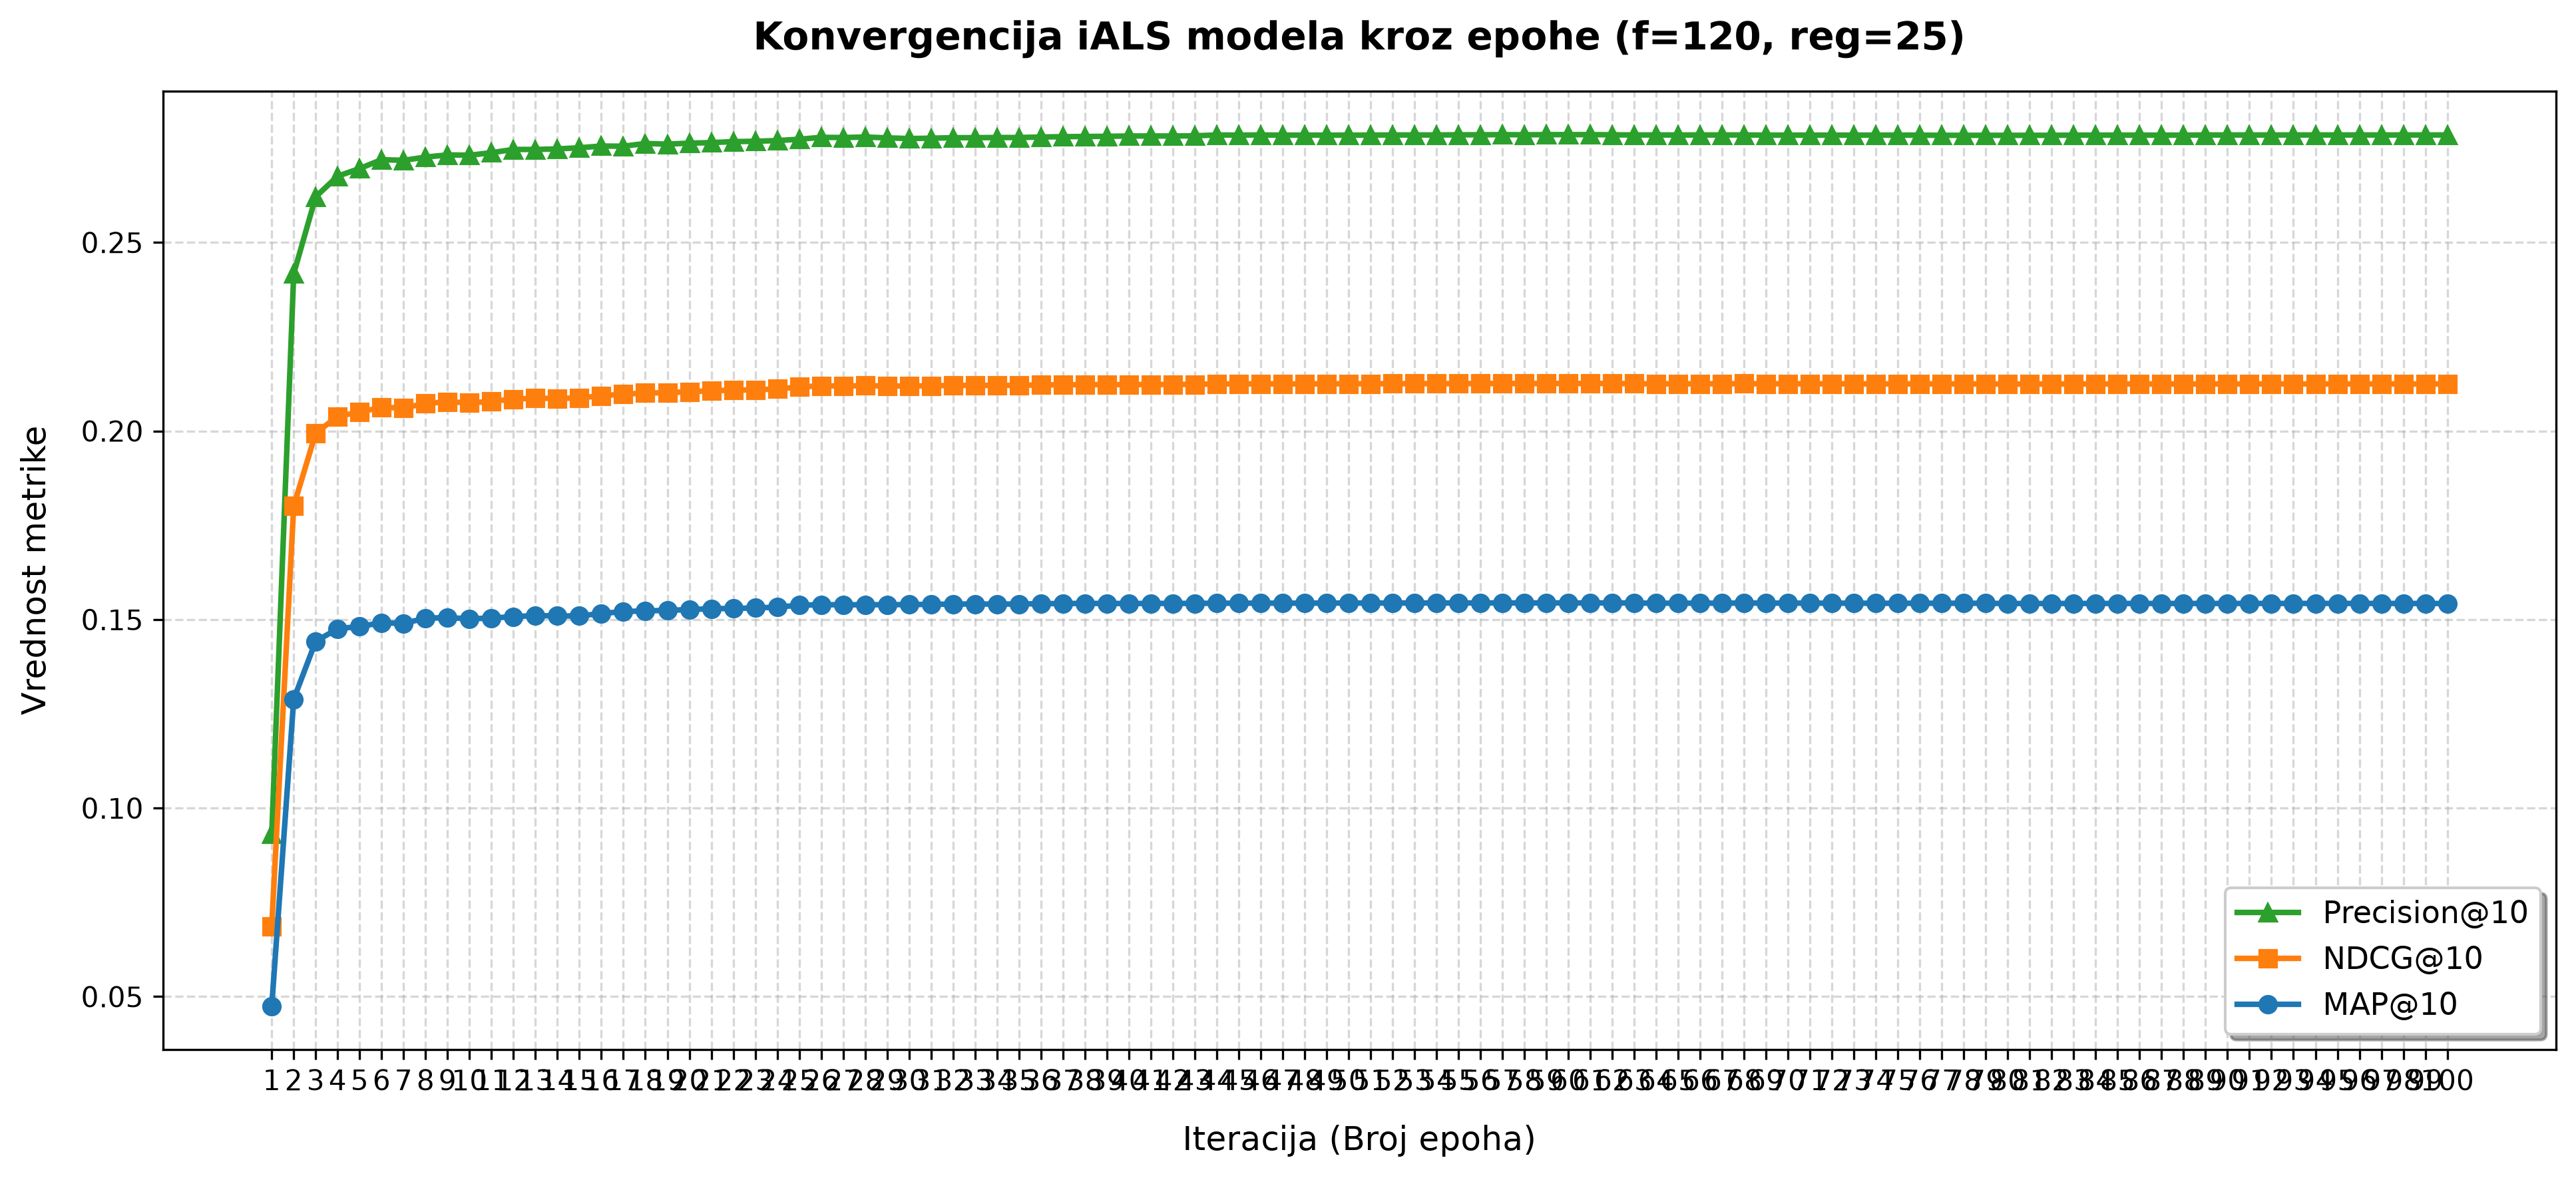

In [ ]:
import matplotlib.pyplot as plt

epohe = range(1, len(istorija_map) + 1)

# postavljamo izduženiji format (širina 13, visina 6) i lepšu pozadinu
plt.figure(figsize=(13, 6), dpi=300) 

plt.plot(epohe, istorija_preciznosti, marker='^', linestyle='-', linewidth=2, markersize=6, color='#2ca02c', label='Precision@10')
plt.plot(epohe, istorija_ndcg, marker='s', linestyle='-', linewidth=2, markersize=6, color='#ff7f0e', label='NDCG@10')
plt.plot(epohe, istorija_map, marker='o', linestyle='-', linewidth=2, markersize=6, color='#1f77b4', label='MAP@10')

plt.title('Konvergencija iALS modela kroz epohe (f=120, reg=25)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Iteracija (Broj epoha)', fontsize=12, labelpad=10)
plt.ylabel('Vrednost metrike', fontsize=12, labelpad=10)

plt.xticks(epohe, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(fontsize=11, loc='lower right', frameon=True, shadow=True)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('konvergencija_modela_izduzeno.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import os
import pickle
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.evaluation import ranking_metrics_at_k

# parametri
broj_faktora = 120
regularizacija = 30  
K_ZA_EVALUACIJU = 10

ime_podfoldera = f'model_manji_f{broj_faktora}_reg{regularizacija}' 
putanja_foldera = os.path.join('sacuvani_modeli', ime_podfoldera)

# matrica za tr (potrebna za filtriranje već slušanih pesama)
user_item_matrix = sparse_item_user.T.tocsr()

# priprema test seta
test_user_indices = df_test_als['user_id_idx'].astype(int).values
test_item_indices = df_test_als['song_id_idx'].astype(int).values
test_values = df_test_als.get('play_count', [1] * len(df_test_als))

test_matrix = csr_matrix(
    (test_values, (test_user_indices, test_item_indices)), 
    shape=user_item_matrix.shape
)

# Promenljive za praćenje najboljeg modela kroz petlju
najbolji_ndcg = -1.0
najbolja_epoha = -1
najbolje_metrike = {}

print(f"Pokrećem evaluaciju test skupa kroz svih 20 epoha za: {ime_podfoldera}\n")

for i in range(1, 101):
    ime_fajla = os.path.join(putanja_foldera, f'epoha_{i:02d}.pkl')
    
    # Provera da li fajl uopšte postoji na disku
    if not os.path.exists(ime_fajla):
        print(f"Fajl {ime_fajla} ne postoji, preskačem...")
        continue
        
    # Učitavanje modela za trenutnu epohu
    with open(ime_fajla, 'rb') as f:
        model = pickle.load(f)
        
    # Pokretanje evaluacije
    metrike = ranking_metrics_at_k(
        model, 
        train_user_items=user_item_matrix, 
        test_user_items=test_matrix, 
        K=K_ZA_EVALUACIJU,
        show_progress=False
    )
    
    trenutni_prec = metrike['precision']
    trenutni_map = metrike['map']
    trenutni_ndcg = metrike['ndcg']
    
    print(f"Epoha {i:02d}: Precision@{K_ZA_EVALUACIJU} = {trenutni_prec:.4f} | MAP@{K_ZA_EVALUACIJU} = {trenutni_map:.4f} | NDCG@{K_ZA_EVALUACIJU} = {trenutni_ndcg:.4f}")
    
    # Logika za pronalaženje najboljeg modela (na osnovu NDCG@10)
    if trenutni_ndcg > najbolji_ndcg:
        najbolji_ndcg = trenutni_ndcg
        najbolja_epoha = i
        najbolje_metrike = metrike

# ISPIS NAJBOLJIH REZULTATA NA KRAJU
print("\n=======================================================")
print(f"  NAJBOLJI REZULTATI NA TEST SETU OSTVARENI U EPOHI: {najbolja_epoha}")
print("=======================================================")

final_metrics_df = pd.DataFrame({
    'Metrika': [f'Precision@{K_ZA_EVALUACIJU}', f'MAP@{K_ZA_EVALUACIJU}', f'NDCG@{K_ZA_EVALUACIJU}'],
    'Vrednost': [najbolje_metrike['precision'], najbolje_metrike['map'], najbolje_metrike['ndcg']]
})

print(final_metrics_df.to_string(index=False))

Pokrećem evaluaciju test skupa kroz svih 20 epoha za: model_manji_f120_reg30

Epoha 01: Precision@10 = 0.1179 | MAP@10 = 0.0602 | NDCG@10 = 0.0839
Epoha 02: Precision@10 = 0.2685 | MAP@10 = 0.1373 | NDCG@10 = 0.1872
Epoha 03: Precision@10 = 0.2957 | MAP@10 = 0.1613 | NDCG@10 = 0.2150
Epoha 04: Precision@10 = 0.3023 | MAP@10 = 0.1664 | NDCG@10 = 0.2210
Epoha 05: Precision@10 = 0.3035 | MAP@10 = 0.1667 | NDCG@10 = 0.2213
Epoha 06: Precision@10 = 0.3041 | MAP@10 = 0.1678 | NDCG@10 = 0.2223
Epoha 07: Precision@10 = 0.3064 | MAP@10 = 0.1658 | NDCG@10 = 0.2215
Epoha 08: Precision@10 = 0.3056 | MAP@10 = 0.1646 | NDCG@10 = 0.2202
Epoha 09: Precision@10 = 0.3051 | MAP@10 = 0.1641 | NDCG@10 = 0.2197
Epoha 10: Precision@10 = 0.3051 | MAP@10 = 0.1640 | NDCG@10 = 0.2196
Epoha 11: Precision@10 = 0.3056 | MAP@10 = 0.1640 | NDCG@10 = 0.2196
Epoha 12: Precision@10 = 0.3063 | MAP@10 = 0.1641 | NDCG@10 = 0.2199
Epoha 13: Precision@10 = 0.3063 | MAP@10 = 0.1642 | NDCG@10 = 0.2201
Epoha 14: Precision@10 = 

In [21]:
with open(r'sacuvani_modeli\model_manji_f120_reg30\epoha_96.pkl', 'rb') as f:
    model = pickle.load(f)

print(r"model sacuvani_modeli\model_manji_f120_reg30\epoha_96.pkl je ucitan")

model sacuvani_modeli\model_manji_f120_reg30\epoha_96.pkl je ucitan


## cosine similarity

In [ ]:
'''import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def kaskadne_preporuke_za_korisnika(target_user_id, als_model, df_train, df_finalni, tfidf_matrix, top_n_als=100, final_top_k=10):
    """
    1. Faza: ALS izdvaja top_n_als potencijalnih pjesama.
    2. Faza: Cosine similarity rangira te pjesme na osnovu korisnikovog profila i izdvaja final_top_k.
    """
    # ----------------------------------------------------
    # 1. FAZA: DOBIVANJE KANDIDATA IZ ALS MODELA
    # ----------------------------------------------------
    # Mapiranje spoljnog user_id u interni indeks ako je potrebno
    # (Pretpostavljamo da koristiš mapiranje iz sveske, npr. user_id_int)
    # Ako tvoj model prima direktno stringove, prilagodi ovaj dio
    
    # Dobijamo preporuke iz ALS-a za korisnika (vraća listu tuple-ova (song_id, score))
    # implicit biblioteka zahtijeva unos korisničkog indeksa i train matrice
    # Za demonstraciju koristimo standardni poziv iz implicit:
    ids, scores = als_model.recommend(target_user_id, train_user_items[target_user_id], N=top_n_als)
    
    # Mapiramo nazad u originalne song_id-eve iz tvog DataFrame-a
    # (Prilagodi mapiranje zavisno od toga kako držiš indekse u svesci)
    als_kandidati_ids = [kodovi_pesama_obrnuto[i] for i in ids] 
    
    # ----------------------------------------------------
    # 2. FAZA: RE-RANGIRANJE POMOĆU KOSINUSNE SLIČNOSTI
    # ----------------------------------------------------
    # Pronalazimo pjesme koje je ovaj korisnik već slušao u trening skupu da napravimo njegov profil
    korisnikove_pesme = df_train[df_train['user_id'] == target_user_id]['song_id'].unique()
    
    if len(korisnikove_pesme) == 0:
        # Ako je korisnik novi (Cold Start), vraćamo samo ALS kandidate ili najpopularnije
        return als_kandidati_ids[:final_top_k]
    
    # Nalazimo indekse korisnikovih pjesama u df_finalni tabeli da bismo izvukli njihove vektore iz tfidf_matrix
    indeksi_slusanih = df_finalni[df_finalni['song_id'].isin(korisnikove_pesme)].index.tolist()
    
    # Kreiramo Profil Korisnika (prosek vektora svih pjesama koje je odslušao)
    vektori_slusanih = tfidf_matrix[indeksi_slusanih]
    korisnicki_profil_vektor = np.asarray(vektori_slusanih.mean(axis=0))
    
    # Izvačimo indekse ALS kandidata iz df_finalni da uzmemo njihove karakteristike
    indeksi_kandidata = df_finalni[df_finalni['song_id'].isin(als_kandidati_ids)].index.tolist()
    vektori_kandidata = tfidf_matrix[indeksi_kandidata]
    
    # Računamo kosinusnu sličnost između korisničkog profila i svih ALS kandidata
    slicnosti = cosine_similarity(korisnicki_profil_vektor.reshape(1, -1), vektori_kandidata).flatten()
    
    # Pakujemo u DataFrame radi lakšeg sortiranja
    df_rangiranje = pd.DataFrame({
        'song_id': [df_finalni.iloc[idx]['song_id'] for idx in indeksi_kandidata],
        'hibridni_skor': slicnosti
    })
    
    # Sortiramo po najvećoj kosinusnoj sličnosti i uzimamo finalnih TOP 10
    finalne_preporuke = df_rangiranje.sort_values(by='hibridni_skor', ascending=False).head(final_top_k)
    
    return finalne_preporuke

# ==========================================
# PRIMJER POKRETANJA ZA JEDNOG KORISNIKA
# ==========================================
# test_user = "bn"
# top_10_hibrid = kaskadne_preporuke_za_korisnika(
#     target_user_id=test_user, 
#     als_model=model, # Tvoj istrenirani ALS
#     df_train=df_train, 
#     df_finalni=df_finalni, 
#     tfidf_matrix=tfidf_matrix, 
#     top_n_als=100, # ALS izdvaja 100 kandidata
#     final_top_k=10 # Content-Based odatle bira najboljih 10
# )
# print(top_10_hibrid)'''

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# =====================================================================
# KORAK 1: Pravljenje inverznog rečnika za pesme (int -> string song_id)
# =====================================================================
# Pošto imamo song_map (string -> int), pravimo obrnuti rečnik za ALS preporuke
inv_song_map = {v: k for k, v in song_map.items()}

# Pravimo i brzi rečnik za indeksiranje u tfidf_matrix preko df_finalni
song_to_matrix_idx = {song: idx for idx, song in enumerate(df_finalni['song_id'])}


# =====================================================================
# KORAK 2: Funkcija za evaluaciju kaskadnog hibrida (ALS -> Cosine)
# =====================================================================
def evaluiraj_kaskadni_hibrid(df_train, df_test, df_finalni, tfidf_matrix, als_model, user_map, inv_song_map, top_n_als, K):
    precisions = []
    aps = []
    ndcgs = []
    
    # Grupisanje radi brže evaluacije (izbegavamo milione query-ja nad DataFrame-om)
    test_korisnici = df_test.groupby('user_id')['song_id'].apply(list).to_dict()
    train_korisnici = df_train.groupby('user_id')['song_id'].apply(list).to_dict()
    
    print(f"Započinjem evaluaciju kaskadnog hibrida za {len(test_korisnici)} korisnika...")
    
    for uski_brojac, (target_user_id, stvarne_test_pesme) in enumerate(test_korisnici.items()):
        # Korisnik mora postojati u train-u i u našem rečniku mapiranja
        if target_user_id not in user_map or target_user_id not in train_korisnici:
            continue
            
        user_idx = user_map[target_user_id]
        korisnikove_pesme_train = train_korisnici[target_user_id]
        
        # ----------------------------------------------------
        # FAZA 1: Generisanje kandidata pomoću ALS-a
        # ----------------------------------------------------
        # Prosleđujemo user_idx. implicit biblioteka zahteva i user-item matricu (što je transponovana tvoja matrica)
        # Ako je nemamo izdvojenu, prosleđujemo prazan/dummy niz jer je model već istreniran
        try:
            # Pokušavamo da izvučemo preporuke preko transponovane matrice (User-Item format)
            ids, scores = als_model.recommend(user_idx, sparse_item_user.T.tocsr()[user_idx], N=top_n_als)
        except Exception:
            # Fallback ako se oblici u tvojoj verziji implicit-a razlikuju
            ids, scores = als_model.recommend(user_idx, None, N=top_n_als)
            
        # Pretvaramo int indekse iz ALS-a nazad u string song_id-eve
        als_kandidati_ids = [inv_song_map[i] for i in ids if i in inv_song_map]
        # Zadržavamo samo one koji postoje u content-based matrici (df_finalni)
        als_kandidati_ids = [s for s in als_kandidati_ids if s in song_to_matrix_idx]
        
        if not als_kandidati_ids:
            continue
            
        # ----------------------------------------------------
        # FAZA 2: Re-rangiranje kandidata pomoću Kosinusne Sličnosti
        # ----------------------------------------------------
        # Nalazimo indekse u tfidf_matrix za pesme koje je korisnik slušao u treningu
        indeksi_slusanih = [song_to_matrix_idx[s] for s in korisnikove_pesme_train if s in song_to_matrix_idx]
        
        if len(indeksi_slusanih) == 0:
            # Ako iz nekog razloga nemamo žanrovske podatke za train pesme, uzimamo samo top K iz ALS-a
            preporuceni_ids = als_kandidati_ids[:K]
        else:
            # Kreiramo profil korisnika kao prosečan TF-IDF vektor pesama koje je slušao
            vektori_slusanih = tfidf_matrix[indeksi_slusanih]
            korisnicki_profil_vektor = np.asarray(vektori_slusanih.mean(axis=0)).reshape(1, -1)
            
            # Izvlačimo TF-IDF vektore za ALS kandidate
            indeksi_kandidata = [song_to_matrix_idx[s] for s in als_kandidati_ids]
            vektori_kandidata = tfidf_matrix[indeksi_kandidata]
            
            # Računamo kosinusnu sličnost između korisničkog profila i svih ALS kandidata
            slicnosti = cosine_similarity(korisnicki_profil_vektor, vektori_kandidata).flatten()
            
            # Sortiramo kandidate od najveće sličnosti ka najmanjoj i uzimamo Top K (K=10)
            top_kand_indeksi = np.argsort(slicnosti)[::-1][:K]
            preporuceni_ids = [als_kandidati_ids[idx] for idx in top_kand_indeksi]
            
        # ----------------------------------------------------
        # FAZA 3: Računanje standardnih evaluacionih metrika
        # ----------------------------------------------------
        stvarne_test_pesme_set = set(stvarne_test_pesme)
        pogoci = [pesma for pesma in preporuceni_ids if pesma in stvarne_test_pesme_set]
        broj_pogodaka = len(pogoci)
        
        # a) Precision@K
        precisions.append(broj_pogodaka / K)
        
        # b) MAP@K
        ap_suma = 0.0
        broj_pogodaka_do_sada = 0
        for i, pesma in enumerate(preporuceni_ids):
            if pesma in stvarne_test_pesme_set:
                broj_pogodaka_do_sada += 1
                ap_suma += broj_pogodaka_do_sada / (i + 1)
        aps.append(ap_suma / min(len(stvarne_test_pesme), K) if len(stvarne_test_pesme) > 0 else 0)
        
        # c) NDCG@K
        dcg = 0.0
        for i, pesma in enumerate(preporuceni_ids):
            if pesma in stvarne_test_pesme_set:
                dcg += 1.0 / np.log2(i + 2)
                
        idcg = sum([1.0 / np.log2(i + 2) for i in range(min(broj_pogodaka, K))])
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
        
        # Ispis napretka na svakih 500 korisnika da znaš da kod radi
        if uski_brojac % 500 == 0 and uski_brojac > 0:
            print(f"Obrađeno {uski_brojac} korisnika...")

    # Pakovanje u finalni DataFrame za prikaz profesoru
    metrics_df = pd.DataFrame({
        'Metrika': [f'Precision@{K}', f'MAP@{K}', f'NDCG@{K}'],
        'Vrednost': [np.mean(precisions), np.mean(aps), np.mean(ndcgs)]
    })
    
    return metrics_df


# =====================================================================
# KORAK 3: Pokretanje hibridne evaluacije
# =====================================================================
# Pokrećemo nad df_test_als koji već ima filtrirane i spremne podatke
rezultati_kaskadnog_hibrida = evaluiraj_kaskadni_hibrid(
    df_train=df_als,                  # Tvoj očišćeni train bez duplikata
    df_test=df_test_als,              # Tvoj pripremljeni test set
    df_finalni=df_finalni,            # Tabela sa tekstualnim podacima za TF-IDF
    tfidf_matrix=tfidf_matrix,        # Tvoja pre-runovana TF-IDF matrica
    als_model=model,                  # Tvoj istrenirani ALS model (promenljiva 'model')
    user_map=user_map,                # Tvoj rečnik iz sveske
    inv_song_map=inv_song_map,        # Naš sveže napravljeni inverzni rečnik
    top_n_als=2,                      # ALS prvo odabere top 100 pesama iz cele baze
    K=2                               # Kosinusna sličnost odatle izdvaja finalnih top 10
)

print("\n=======================================================")
print("  REZULTATI KASKADNOG HIBRIDA NA TEST SETU")
print("=======================================================")
print(rezultati_kaskadnog_hibrida.to_string(index=False))

Započinjem evaluaciju kaskadnog hibrida za 21792 korisnika...
Obrađeno 500 korisnika...
Obrađeno 1000 korisnika...
Obrađeno 1500 korisnika...
Obrađeno 2000 korisnika...
Obrađeno 2500 korisnika...
Obrađeno 3000 korisnika...
Obrađeno 3500 korisnika...
Obrađeno 4000 korisnika...
Obrađeno 4500 korisnika...
Obrađeno 5000 korisnika...
Obrađeno 5500 korisnika...
Obrađeno 6000 korisnika...
Obrađeno 6500 korisnika...
Obrađeno 7000 korisnika...
Obrađeno 7500 korisnika...
Obrađeno 8000 korisnika...
Obrađeno 8500 korisnika...
Obrađeno 9000 korisnika...
Obrađeno 9500 korisnika...
Obrađeno 10000 korisnika...
Obrađeno 10500 korisnika...
Obrađeno 11000 korisnika...
Obrađeno 11500 korisnika...
Obrađeno 12000 korisnika...
Obrađeno 12500 korisnika...
Obrađeno 13000 korisnika...
Obrađeno 13500 korisnika...
Obrađeno 14000 korisnika...
Obrađeno 14500 korisnika...
Obrađeno 15000 korisnika...
Obrađeno 15500 korisnika...
Obrađeno 16000 korisnika...
Obrađeno 16500 korisnika...
Obrađeno 17000 korisnika...
Obrađe